# Lab Experiment 5: Linear Regression through Gradient Descent

**Aim:** Implement linear regression with batch gradient descent on the Student Performance dataset and evaluate the model.

## 1. Import libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2. Load and inspect the dataset

`student-mat.csv` contains Mathematics-course student records. `G3` is the final grade (0–20).

In [22]:
file_path = 'student+performance/student/student-mat.csv'
df = pd.read_csv(file_path, sep=';')

print('Dataset shape:', df.shape)

print('\nColumn info:')
df.info()

print('\nMissing Values')
display(df.isnull().sum())
print('Total missing values:', df.isnull().sum().sum())

dup_count = df.duplicated().sum()
print(f'\nDuplicate Rows: {dup_count}')

display(df.head())

print('\nDescriptive statistics:')
display(df.describe())

Dataset shape: (395, 33)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  high

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing values: 0

Duplicate Rows: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Descriptive statistics:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


**Interpretation:** Dataset has 395 rows and 33 columns. No missing values and no duplicates, so the data is ready for preprocessing.

## 3. Preprocess and split the data

Categorical columns are one-hot encoded and numeric columns are standardized. `G1` and `G2` are dropped because they are earlier grades and would make predicting `G3` too easy (data leakage).

In [29]:

# Target Variable
y = df['G3'].astype(float)
# Input Features (drop G1/G2 to avoid leakage)
X = df.drop(columns=['G1', 'G2', 'G3'])
print('\nFeatures Shape:', X.shape)
print('Target Shape:', y.shape)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print('\nTraining Samples:', X_train_raw.shape[0])
print('Testing Samples:', X_test_raw.shape[0])

numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

print('\nEncoding Categorical Columns')
print('Categorical columns to encode:', list(categorical_features))
print('Numeric columns to scale:', list(numeric_features))

preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

print('\nFeature Scaling')
X_train = preprocessor.fit_transform(X_train_raw).astype(float)
X_test = preprocessor.transform(X_test_raw).astype(float)

print('Categorical columns encoded successfully (One-Hot Encoding).')
print('Feature Scaling Performed (StandardScaler on numeric features).')
print('Scaled Training Features Shape:', X_train.shape)
print('Scaled Testing Features Shape :', X_test.shape)


Features Shape: (395, 30)
Target Shape: (395,)

Training Samples: 316
Testing Samples: 79

Encoding Categorical Columns
Categorical columns to encode: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numeric columns to scale: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Feature Scaling
Categorical columns encoded successfully (One-Hot Encoding).
Feature Scaling Performed (StandardScaler on numeric features).
Scaled Training Features Shape: (316, 56)
Scaled Testing Features Shape : (79, 56)


**Interpretation:** Categorical columns are one-hot encoded and numeric columns are scaled. Target is `G3`. Data is split 80:20 (316 train, 79 test). Preprocessing is fit only on the training set.

## 4. Implement batch gradient descent

The loss used is Mean Squared Error (MSE). A bias column is added so the model can learn an intercept.

In [24]:
def gradient_descent(X, y, learning_rate, iterations=3000):
    """Return the learned parameters and MSE at every iteration."""
    X_bias = np.c_[np.ones(X.shape[0]), X]
    theta = np.zeros(X_bias.shape[1])
    loss_history = []
    y_array = y.to_numpy()

    for _ in range(iterations):
        predictions = X_bias @ theta
        error = predictions - y_array
        loss_history.append(np.mean(error ** 2))
        gradient = (2 / len(y_array)) * (X_bias.T @ error)
        theta -= learning_rate * gradient

    return theta, loss_history

**Interpretation:** Batch gradient descent updates the weights step by step to reduce MSE until the model converges.

## 5. Compare learning rates and plot convergence

Learning rate 0.001: initial MSE = 127.630, final training MSE = 15.248
Learning rate 0.01 : initial MSE = 127.630, final training MSE = 14.939
Learning rate 0.05 : initial MSE = 127.630, final training MSE = 14.939


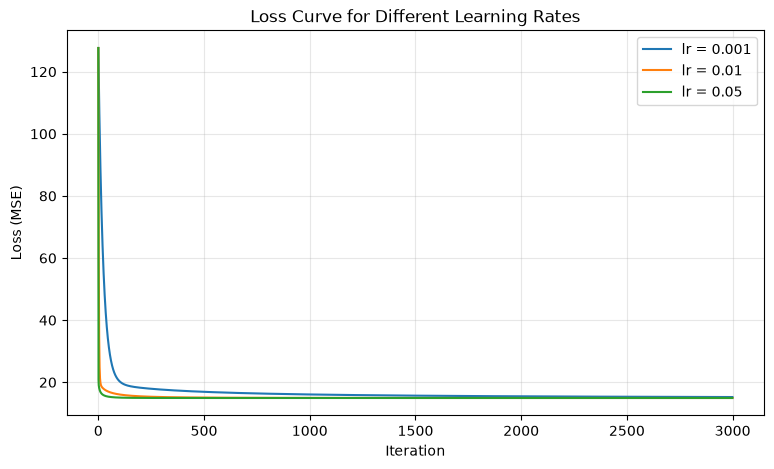

In [25]:
learning_rates = [0.001, 0.01, 0.05]
results = {}

for lr in learning_rates:
    theta, history = gradient_descent(X_train, y_train, learning_rate=lr)
    results[lr] = {'theta': theta, 'history': history}
    print(f'Learning rate {lr:<5}: initial MSE = {history[0]:.3f}, final training MSE = {history[-1]:.3f}')

plt.figure(figsize=(9, 5))
for lr, result in results.items():
    plt.plot(result['history'], label=f'lr = {lr}')
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Loss Curve for Different Learning Rates')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretation:** Learning rate 0.05 converges fastest. 0.01 also works well but is slower. 0.001 is too small and does not fully converge in 3000 iterations.

## 5b. 3D view of gradient descent

A full model has many weights, so we cannot plot all of them in 3D. Here we use **one feature** (`studytime`) plus the intercept, and show how gradient descent moves on the cost surface.

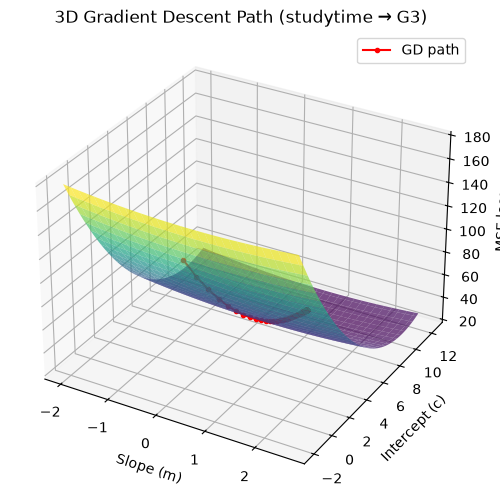

Final slope m = 0.633, intercept c = 10.326, MSE = 20.603


In [26]:
from mpl_toolkits.mplot3d import Axes3D

# Use one scaled feature so we can plot intercept (c) and slope (m)
x_1d = X_train_raw[['studytime']].to_numpy().astype(float)
x_1d = (x_1d - x_1d.mean()) / x_1d.std()
y_1d = y_train.to_numpy()

m, c = 0.0, 0.0
lr_3d = 0.05
m_hist, c_hist, loss_hist = [], [], []

for _ in range(200):
    pred = m * x_1d.flatten() + c
    error = pred - y_1d
    loss = np.mean(error ** 2)
    m_hist.append(m)
    c_hist.append(c)
    loss_hist.append(loss)
    dm = (2 / len(y_1d)) * np.dot(error, x_1d.flatten())
    dc = (2 / len(y_1d)) * np.sum(error)
    m -= lr_3d * dm
    c -= lr_3d * dc

# Cost surface around the path
m_vals = np.linspace(min(m_hist) - 2, max(m_hist) + 2, 60)
c_vals = np.linspace(min(c_hist) - 2, max(c_hist) + 2, 60)
M, C = np.meshgrid(m_vals, c_vals)
J = np.zeros_like(M)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        pred = M[i, j] * x_1d.flatten() + C[i, j]
        J[i, j] = np.mean((pred - y_1d) ** 2)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(M, C, J, cmap='viridis', alpha=0.7)
ax.plot(m_hist, c_hist, loss_hist, color='red', marker='o', markersize=3, label='GD path')
ax.set_xlabel('Slope (m)')
ax.set_ylabel('Intercept (c)')
ax.set_zlabel('MSE loss')
ax.set_title('3D Gradient Descent Path (studytime → G3)')
ax.legend()
plt.show()

print(f'Final slope m = {m:.3f}, intercept c = {c:.3f}, MSE = {loss_hist[-1]:.3f}')

**Interpretation:** The red line is the gradient descent path. It starts at a high loss and moves downhill on the cost surface toward the minimum. The local minimum found is around slope **m ≈ 0.633**, intercept **c ≈ 10.326**, with MSE ≈ **20.603**.

## 6. Evaluate the selected model

The learning rate of 0.05 is selected because it gives the lowest final training loss among the tested values.

In [27]:
best_lr = 0.05
best_theta = results[best_lr]['theta']
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]
y_pred = X_test_bias @ best_theta

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE : {mae:.3f}')
print(f'MSE : {mse:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²  : {r2:.3f}')

MAE : 3.395
MSE : 17.604
RMSE: 4.196
R²  : 0.141


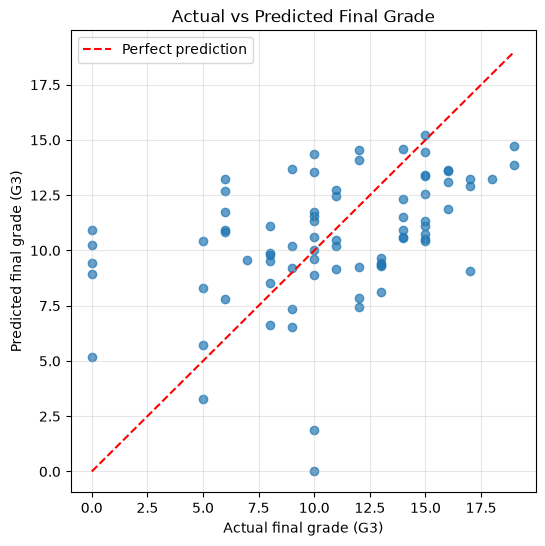

In [28]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(limits, limits, 'r--', label='Perfect prediction')
plt.xlabel('Actual final grade (G3)')
plt.ylabel('Predicted final grade (G3)')
plt.title('Actual vs Predicted Final Grade')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretation:** MAE is about 3.4 and RMSE about 4.2, so predictions are off by a few grade points. R² is 0.14, which is low because we did not use G1 and G2.

## 7. Final interpretation

**Convergence:** The loss decreases and then becomes flat, so gradient descent converged. Learning rate 0.05 worked best.

**Performance:** MAE ≈ 3.4, RMSE ≈ 4.2, R² ≈ 0.14. The model is okay but not very accurate, since background features alone cannot fully explain the final grade.